# Case Study: Portfolio Optimization and GitHub Classroom

In this notebook, we will use an example from Portfolio Optimization 101 to practice the test-driven development patterns that we will use for homework assignments in this class.

In [1]:
# always import all necessary libraries at the top of the file
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import config
import scipy.optimize

MANUAL_DATA_DIR = config.MANUAL_DATA_DIR

## Data

We'll begin by loading data from the file `data_port.csv`. This contains a matrix of prices, each row corresponding to a day. The columns, in order from left to right, correspond to the S&P 500 index, crude oil index, and the U.S. 10-year Treasury index.

In [2]:
data_assets = pd.read_csv(MANUAL_DATA_DIR / 'data_assets.csv', parse_dates=['date'])
data_assets = data_assets.set_index('date')

In [3]:
data_assets.dtypes

sp500            float64
USD_index        float64
crude_oil        float64
HYG              float64
treasury_10yr    float64
dtype: object

In [4]:
data_assets.head()

,sp500,USD_index,crude_oil,HYG,treasury_10yr
date,,,,,
2013-08-07,1690.91,81.287,87.83,91.36,2.5986
2013-08-08,1697.48,80.977,87.50,91.56,2.5892
2013-08-09,1691.42,81.126,87.95,91.57,2.5784
2013-08-12,1689.47,81.333,88.19,91.49,2.6206
2013-08-14,1685.39,81.711,88.47,91.31,2.7136


In [5]:
data_assets.tail()

,sp500,USD_index,crude_oil,HYG,treasury_10yr
date,,,,,
2015-09-03,1951.13,96.405,46.75,86.05,2.1596
2015-09-04,1921.22,96.229,46.05,85.96,2.1244
2015-09-08,1969.41,95.985,45.94,86.43,2.1828
2015-09-09,1942.04,96.012,44.15,86.32,2.2006
2015-09-10,1952.29,95.456,45.92,86.53,2.2220


 Calculate the matrix of history of returns for the three assets. Calculate both the log-return (`rets_log`) and the level-return (`rets`). The log and level returns are defined as:
 
 - log-return, $\tilde r_t = \log \left( \frac{P_{t+1}}{P_t} \right)$
 - level-return, $r_t = \frac{P_{t+1}}{P_t} - 1$

In [6]:
rets_log = np.log(data_assets / data_assets.shift(1))
rets = data_assets / data_assets.shift(1) - 1


In [7]:
data_assets.head()

,sp500,USD_index,crude_oil,HYG,treasury_10yr
date,,,,,
2013-08-07,1690.91,81.287,87.83,91.36,2.5986
2013-08-08,1697.48,80.977,87.50,91.56,2.5892
2013-08-09,1691.42,81.126,87.95,91.57,2.5784
2013-08-12,1689.47,81.333,88.19,91.49,2.6206
2013-08-14,1685.39,81.711,88.47,91.31,2.7136


In [8]:
rets.head()

,sp500,USD_index,crude_oil,HYG,treasury_10yr
date,,,,,
2013-08-07,NaN,NaN,NaN,NaN,NaN
2013-08-08,0.003885,-0.003814,-0.003757,0.002189,-0.003617
2013-08-09,-0.003570,0.001840,0.005143,0.000109,-0.004171
2013-08-12,-0.001153,0.002552,0.002729,-0.000874,0.016367
2013-08-14,-0.002415,0.004648,0.003175,-0.001967,0.035488


Calculate a matrix of cumulative returns of the assets, named `rets_cum_log` and `rets_cum`. Recall that the cumulative return is simply

 - log-return, $\tilde r_{t,h} = \log \left( \frac{P_{t+h}}{P_t} \right)$
 - level-return, $r_{t,h} = \frac{P_{t+h}}{P_t} - 1$.
 
For this exercise, let $t=0$ (2013-08-29) and compute the cumulative returns for all available values of $h$.

In [9]:
rets_cum_log = np.cumsum(rets_log, axis=0)
rets_cum = np.cumprod(rets + 1, axis=0) - 1

* Now, plot the cumulative returns.

<Axes: xlabel='date'>

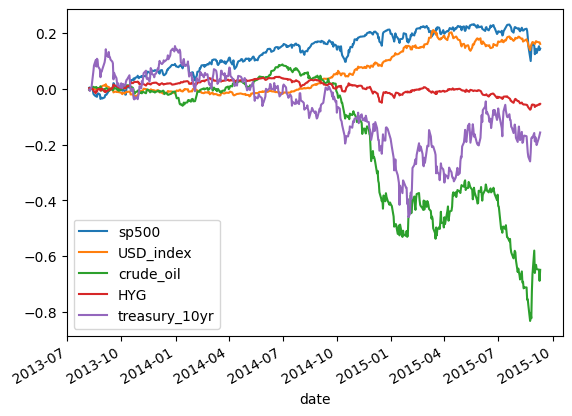

In [10]:
rets_cum_log.plot()

## Arithmetic vs Geometric Averages

Suppose we want to compute the average returns of each of these assets. To do this, we must first choose whether we want to use an *arithmetic average* or a *geometric average*. Let $r_t$ be the net return (e.g., 0.03 for a 3% gain) and let $R_t = 1 + r_t$ be the gross return.
An arithmetic average is familiarly defined
$$
\bar r_{arith} = \sum_{t=1}^T r_t.
$$
The geometric average is defined as
$$
\bar r_{geom} = \left(\prod_{t=1}^T (1+r_t) \right)^{1/T} - 1 = \exp\left(\frac 1 T \sum_{t=1}^T \log (1+r_t)\right) - 1.
$$


We will complete the following exercise to understand the practical difference between the two.

* Construct an asset with the following sequence of returns. Let $r_1 = P_1/P_0 = 10\% = 0.10$, then $r_2 = -0.1$, $r_3 = 0.1$, ..., $r_{100} = -0.1$. Save this in a vector called `example_rets`.

In [11]:
example_rets = np.zeros(100)
example_rets[0::2] = 0.06
example_rets[1::2] = -0.06

In [12]:
example_rets

array([ 0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06,
       -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,
        0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06,
       -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,
        0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06,
       -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,
        0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06,
       -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,
        0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06,
       -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,
        0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06, -0.06,  0.06,
       -0.06])

* What is the arithmetic average of these returns?

In [13]:
np.mean(example_rets)

0.0

* What is the geometric average of these returns?

In [14]:
np.exp(np.mean(np.log(1+example_rets))) - 1

-0.0018016229225775726

* Now, suppose that $P_0 = 100$. This will allow us to calculate the prices for the rest of the periods. Compute the prices $P_t$ for $t=1,...,100$. Save this in a vector called `example_prices`.

A good way of doing this is to use the method `.cumprod()`. This will take the cumulative product of a vector. So `np.array([1,2,3]).cumprod()` returns `array([1, 2, 6], dtype=int32)`. A useful hint is to also note that we could perform operations together like this: `(1 + np.array([0,1,2])).cumprod()` would return `array([1, 2, 6], dtype=int32)`.

In [15]:
example_prices = 100 * (1+example_rets).cumprod()
example_prices

array([106.        ,  99.64      , 105.6184    ,  99.281296  ,
       105.23817376,  98.92388333, 104.85931633,  98.56775735,
       104.4818228 ,  98.21291343, 104.10568823,  97.85934694,
       103.73090776,  97.50705329, 103.35747649,  97.1560279 ,
       102.98538957,  96.8062662 , 102.61464217,  96.45776364,
       102.24522946,  96.11051569, 101.87714663,  95.76451783,
       101.5103889 ,  95.41976557, 101.1449515 ,  95.07625441,
       100.78082968,  94.7339799 , 100.41801869,  94.39293757,
       100.05651382,  94.053123  ,  99.69631038,  93.71453175,
        99.33740366,  93.37715944,  98.979789  ,  93.04100166,
        98.62346176,  92.70605406,  98.2684173 ,  92.37231226,
        97.914651  ,  92.03977194,  97.56215826,  91.70842876,
        97.21093449,  91.37827842,  96.86097512,  91.04931661,
        96.51227561,  90.72153907,  96.16483142,  90.39494153,
        95.81863803,  90.06951974,  95.47369093,  89.74526947,
        95.12998564,  89.4221865 ,  94.78751769,  89.10

* Plot the vector of returns `example_prices`. Do you see a pattern? Is the pattern you see helpfully summarized by the arithmetic average that you previously computed? Why or why not?

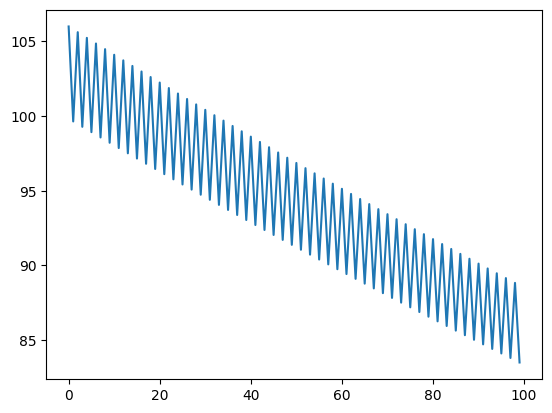

In [16]:
# The arithmetic average told us that the average return was zero. Prices are clearly going down over time, though. The geometric average does reflect this fact, though.
plt.plot(example_prices)

**Discussion**

* What mathematical principal is at play here?
* Note that for small $x$, $log(1 + x) \approx x$. So for most cases of asset returns, $\log(1 + r_t) \approx r_t$. Thus, we will often just use log returns for our calculations. This has the advantage that when we calculate averages of log returns, we are calculating geometric averages of level returns.
* The log returns $\log(P_{t+\tau}/P_t)$ are also sometimes called the continuously compounded returns. That is because, under continuous compounding, $P_{t+\tau} = P_t e^{r \tau}$. If $\tau = .5$ represented a period of 6 months, then 
$$r = \frac{1}{\tau} \log \left( \frac{P_{t+\tau}}{P_t}\right)$$
is the annualized continuously compounded rate of return over those 6 months. A helpful derivation to see this is
$$
\lim_{n\rightarrow \infty} P\left(1 + \frac{r}{n}\right)^{nt} = P e^{rt},
$$
where $n$ is the frequency of compounding per period.

## Plots

Create a plot of the price history of the S&P 500.

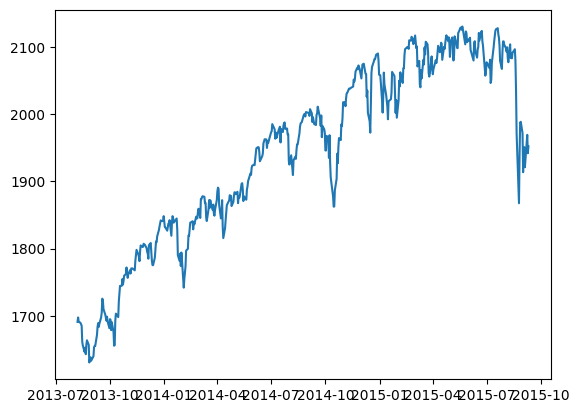

In [17]:
plt.plot(data_assets['sp500'])

In a separate figure, create 4 sub-plots of cumulative returns. That is, plot the history of cumulative returns for each of the 3 assets as well as the equal-weighted portfolio. Use pyplot's `subplot` function.

You can check here to see Crude Oil prices to verify that this looks correct: http://www.macrotrends.net/1369/crude-oil-price-history-chart

In [18]:
rets_cum["ew_portfolio"] = rets_cum.mean(axis=1)

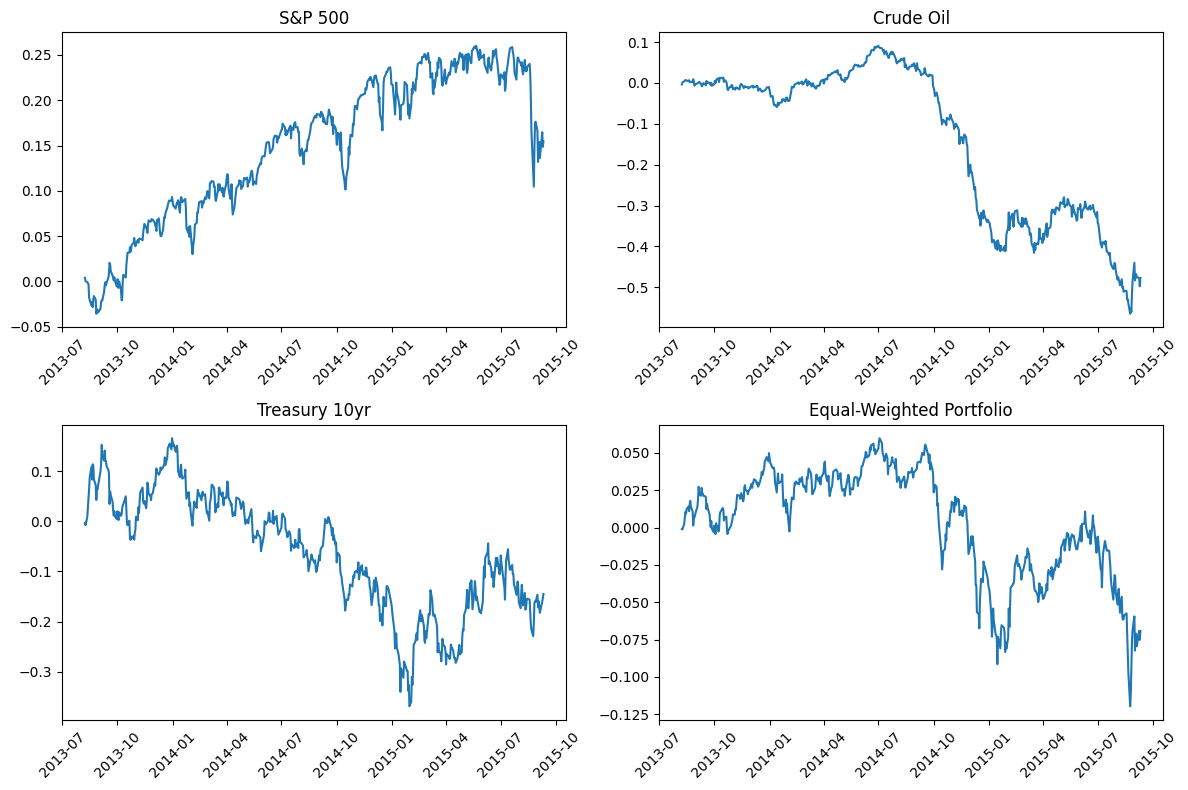

In [19]:
plt.figure(figsize=(12, 8))  # Make figure larger for better readability

plt.subplot(2,2,1)
plt.plot(rets_cum["sp500"])
plt.xticks(rotation=45)  # Rotate dates
plt.title('S&P 500')

plt.subplot(2,2,2)
plt.plot(rets_cum["crude_oil"])
plt.xticks(rotation=45)
plt.title('Crude Oil')

plt.subplot(2,2,3)
plt.plot(rets_cum["treasury_10yr"])
plt.xticks(rotation=45)
plt.title('Treasury 10yr')

plt.subplot(2,2,4)
plt.plot(rets_cum["ew_portfolio"])
plt.xticks(rotation=45)
plt.title('Equal-Weighted Portfolio')

# Add spacing between subplots to prevent overlap
plt.tight_layout()

Make the same plot as above again. However, this time, make sure that the y-axis is the same on each plot. You can do this the manually using pyplot's `ylim` (note the corresponding `xlim` function) or you can do this the better way using pyplot's shared axis feature seen here: https://matplotlib.org/gallery/subplots_axes_and_figures/shared_axis_demo.html#sphx-glr-gallery-subplots-axes-and-figures-shared-axis-demo-py

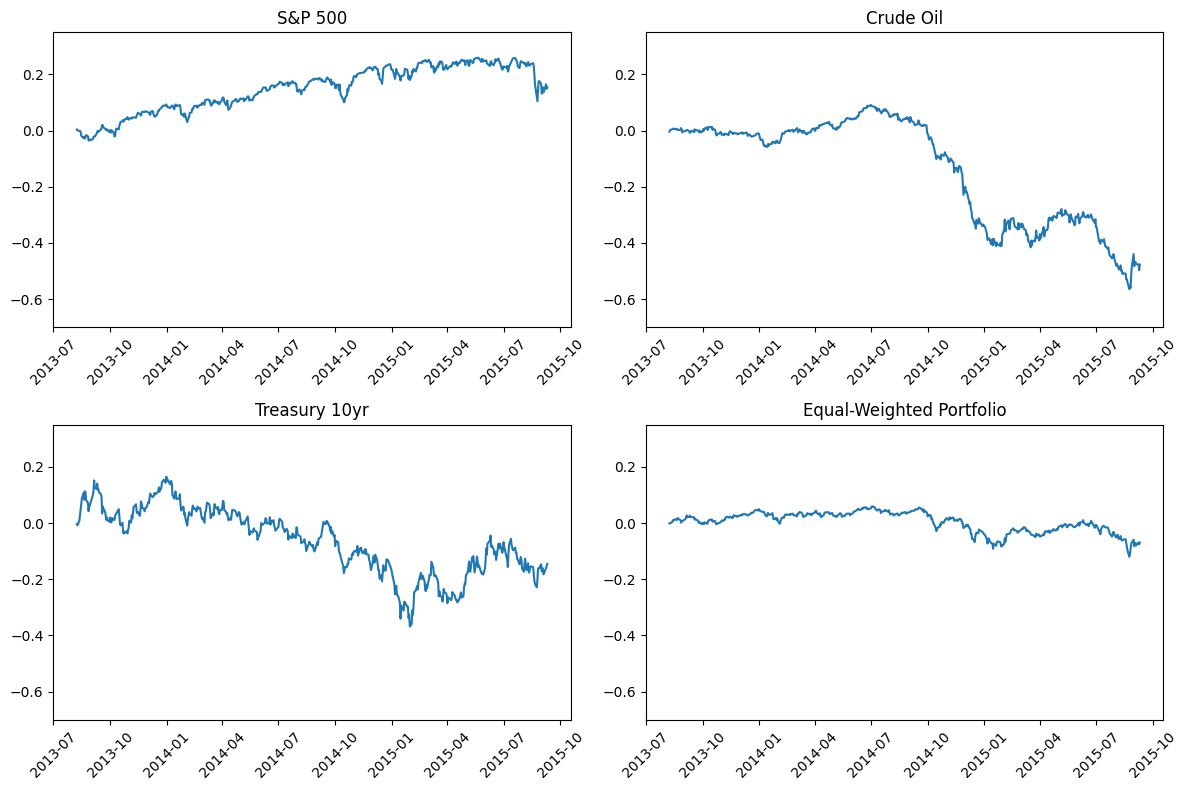

In [20]:
plt.figure(figsize=(12, 8))  # Make figure larger for better readability

plt.subplot(2,2,1)
plt.plot(rets_cum["sp500"])
plt.xticks(rotation=45)  # Rotate dates
plt.ylim((-.7,.35))
plt.title('S&P 500')

plt.subplot(2,2,2)
plt.plot(rets_cum["crude_oil"])
plt.xticks(rotation=45)
plt.ylim((-.7,.35))
plt.title('Crude Oil')

plt.subplot(2,2,3)
plt.plot(rets_cum["treasury_10yr"])
plt.xticks(rotation=45)
plt.ylim((-.7,.35))
plt.title('Treasury 10yr')

plt.subplot(2,2,4)
plt.plot(rets_cum["ew_portfolio"])
plt.xticks(rotation=45)
plt.ylim((-.7,.35))
plt.title('Equal-Weighted Portfolio')

# Add spacing between subplots to prevent overlap
plt.tight_layout();


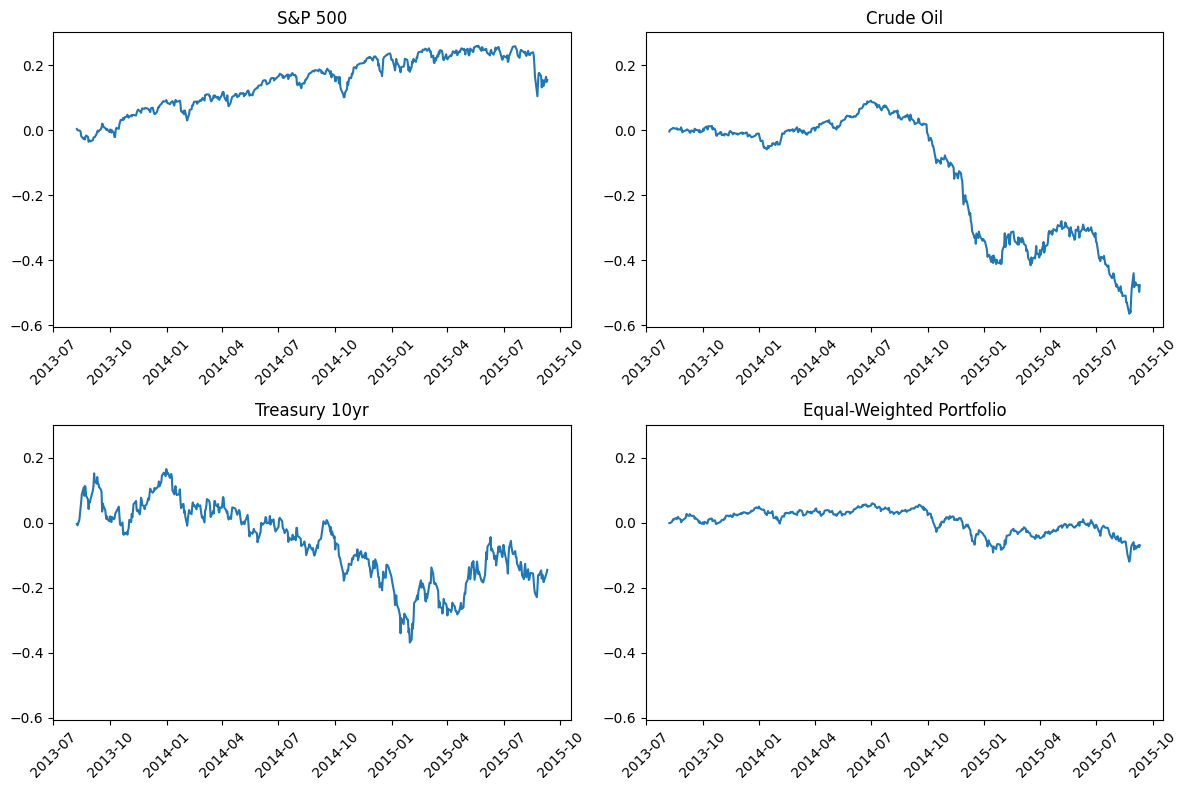

In [21]:
plt.figure(figsize=(12, 8))  # Make figure larger for better readability

ax1 = plt.subplot(221)
plt.plot(rets_cum["sp500"])
plt.xticks(rotation=45)  # Rotate dates
plt.title('S&P 500')

plt.subplot(2,2,2, sharey=ax1)
plt.plot(rets_cum["crude_oil"])
plt.xticks(rotation=45)
plt.title('Crude Oil')

plt.subplot(2,2,3, sharey=ax1)
plt.plot(rets_cum["treasury_10yr"])
plt.xticks(rotation=45)
plt.title('Treasury 10yr')

plt.subplot(2,2,4, sharey=ax1)
plt.plot(rets_cum["ew_portfolio"])
plt.xticks(rotation=45)
plt.title('Equal-Weighted Portfolio')

# Add spacing between subplots to prevent overlap
plt.tight_layout()

Finally, create another figure where you plot both the S&P500 cumulative return history as well as the portfolio cumulative return history in the same figure. Give each plot a label and include a legend. To do this, look up the pyplot `legend` function: https://matplotlib.org/api/_as_gen/matplotlib.pyplot.legend.html

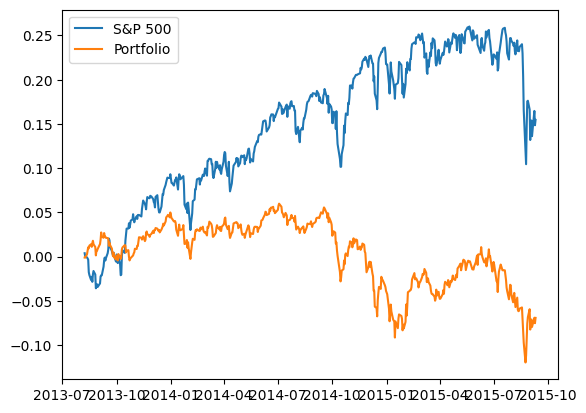

In [22]:
plt.plot(rets_cum["sp500"], label='S&P 500')
plt.plot(rets_cum["ew_portfolio"], label='Portfolio')
plt.legend()

### Histogram to visualize the distribution of returns

In [23]:
rets

,sp500,USD_index,crude_oil,HYG,treasury_10yr
date,,,,,
2013-08-07,NaN,NaN,NaN,NaN,NaN
2013-08-08,0.003885,-0.003814,-0.003757,0.002189,-0.003617
2013-08-09,-0.003570,0.001840,0.005143,0.000109,-0.004171
2013-08-12,-0.001153,0.002552,0.002729,-0.000874,0.016367
2013-08-14,-0.002415,0.004648,0.003175,-0.001967,0.035488
...,...,...,...,...,...
2015-09-03,0.001165,0.006021,0.010811,0.001396,-0.011308
2015-09-04,-0.015330,-0.001826,-0.014973,-0.001046,-0.016299
2015-09-08,0.025083,-0.002536,-0.002389,0.005468,0.027490


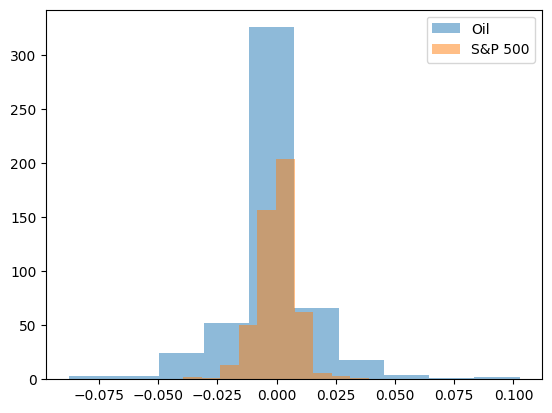

In [24]:
plt.hist(rets["crude_oil"], alpha=.5, label='Oil');
plt.hist(rets["sp500"], alpha=.5, label='S&P 500');
plt.legend()


# Mean-Variance Efficient Portfolios


In this application, we replicate the Markowitz model of portfolio optimization. This model is a model of investor behavior. It models an investor you prefers a portfolio that has higher expected returns and lower variance, *ceteris paribus*. The result of this assumption is that investors (1) choose diversified portfolios and (2) that there exist on a "mean-variance efficient frontier" along which investors choose their portfolios. That is, there are some portfolios that consist of some combinations of assets that are strictly dominated by other combinations of assets. This model  formalizes the notion that an investor should not "put all of his/her eggs in one basket" as well as  the tradeoff between risk and return.

(Note: There are other important lessons that we can learn from this model, but they are beyond the scope of this class. For one, you may search Google for the concept of the "two-portfolio separation theorem." Also note that we are excluding any "risk-free" short-term assets from our analysis here. Also note that Markowitz won the Nobel prize in economics in 1990 for this analysis.)

Suppose that $\mu$ is a column vector of the means of each asset and suppose that $\Sigma$ is the associated variance-covariance matrix. Now, suppose that we create a column vector of weights $w$ that tells us the fraction of our wealth that we invest in each asset. Then, the formulas in matrix notation for the mean and variance of the resulting portfolio are
$$
\mu_p = \mu' w
$$
and
$$
\sigma_p^2 = w' \Sigma w
$$
respectively.


### Global Minimum Variance Portfolio

We'll first start by finding a particular portfolio called the "global minimum variance" portfolio (assuming the absence of a risk-free asset--why?). 

**Discussion** 

 * What is a risk-free asset? Why am I assuming that one doesn't exist?


Consider a portfolio allocation vector, `w`, which sums to 1 and allocates a fraction of the portfolio to each of the 5 securities. For example

    w = np.array([.2, .2, .2, .2, .2])
    
allocates 20% to each asset.

In [25]:
rets = rets * 100

In [26]:
# You may find that this code is helpful for viewing
# the arrays. Suppress will suppress scientific notation
# and precision sets the number of digits to print to
# the screen
np.set_printoptions(precision=2, suppress=True)

 - (1) First, calculate the covariance matrix of the assets. Save it to a variable called `Sigma`. Be sure to set the option of the covariance function to `rowvar=False`, since each column in our matrix is a variable, not each row. Alternatively, you could transpose the matrix.

In [27]:
np.std(rets.dropna(), axis=0)

sp500            0.813926
USD_index        0.450692
crude_oil        1.779660
HYG              0.355573
treasury_10yr    2.114116
dtype: float64

In [47]:
Sigma = np.cov(rets.dropna().T)
Sigma

array([[ 0.66,  0.04,  0.35,  0.19,  0.58],
       [ 0.04,  0.2 , -0.11,  0.  ,  0.22],
       [ 0.35, -0.11,  3.17,  0.2 ,  0.78],
       [ 0.19,  0.  ,  0.2 ,  0.13,  0.06],
       [ 0.58,  0.22,  0.78,  0.06,  4.48]])

In [29]:
np.cov(rets.dropna().T)


array([[ 0.66,  0.04,  0.35,  0.19,  0.58],
       [ 0.04,  0.2 , -0.11,  0.  ,  0.22],
       [ 0.35, -0.11,  3.17,  0.2 ,  0.78],
       [ 0.19,  0.  ,  0.2 ,  0.13,  0.06],
       [ 0.58,  0.22,  0.78,  0.06,  4.48]])

 - (2)
Write an in-line function (a `lambda` function) that calculates the return variance for the allocation using the formula
$$
w' \Sigma w.
$$
Call the function `w`. That is, save the function to a variable called `w`.
Try out your new function using the following portfolio weights:

    w = np.array([1,0,0,0,0])
    w = np.array([.2, .2, .2, .2, .2])
    w = np.array([.4, 0, .2, .2, .2])

In [30]:
f = lambda w: w.transpose() @ Sigma @ w

In [31]:
w = np.array([1,0,0,0,0])
f(w)

0.6638056085925165

In [32]:
w = np.array([.2, .2, .2, .2, .2])
f(w)

0.5303791913224541

In [33]:
w = np.array([.4, 0, .2, .2, .2])
f(w)

0.6789394052607582

 - (3) Write a constraint function called `con`. This takes in the vector of portfolio weights `w` and returns the difference between 1 and the sum of the portfolio weights. The purpose is that if the weights sum to one, then the function returns a zero. The zero indicates that the contraint holds.

In [34]:
con = lambda w: np.sum(w) - 1

 - (4) Minimize this portfolio variance, subject to the constraint that portfolio weights add to 1. 
 
To do this, check out the available constrained optimizers listed in the Scipy documentation: https://docs.scipy.org/doc/scipy/reference/optimize.html

Use sequential least squares: `scipy.optimize.fmin_slsqp`. Set the desired accuracy to `acc=1e-09` and set the option `iprint=2` so that the optimizer will display information at each iteration of the algorithm. You will need to set an initial guess for the optimizer to start from. Set the initial guess to

    w0 = np.array([.2, .2, .2, .2, .2])
    
Save the final results into a new variable called `wstar`.

In [35]:
w0 = np.array([.2, .2, .2, .2, .2])
wstar = scipy.optimize.fmin_slsqp(f, w0, f_eqcons=con, acc=1e-09, iprint=2)
wstar

  NIT    FC           OBJFUN            GNORM
    1     7     7.113506E+00     3.110235E+00
    2    14     3.450102E-01     7.936443E-01
    3    21     8.320087E-02     5.916318E-01
    4    27     7.935392E-02     3.802272E-01
    5    33     7.273365E-02     3.661971E-01
    6    39     7.273360E-02     3.251030E-01
    7    44     7.273360E-02     3.252712E-01
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.07273359519755146
            Iterations: 7
            Function evaluations: 44
            Gradient evaluations: 7


array([-0.13,  0.37,  0.  ,  0.76,  0.01])

 - (5) Test your newly optimized function. Evaluate the covariance of the portfolio at `wstar` and 
    
    `wstar + np.array([0.1, 0, 0, 0, -0.1])`

and

    wstar - np.array([0.1, 0, 0, 0, -0.1])
    
The perturbation will ensure that the constraint still holds. Does `wstar` appear to be an minimum?

**Discussion:**

 * What do I mean when I say that the "perturbation will ensure that the constraint still holds"? 
 * Why is it important for this constraint to hold?

In [36]:
f(wstar)

0.07273359519755146

In [37]:
f(wstar + np.array([0.1, 0, 0, 0, -0.1]))

0.11255769809558766

In [38]:
f(wstar - np.array([0.1, 0, 0, 0, -0.1]))

0.11255830632531705

### Mean-Variance Efficient Portfolios

We now consider the case of constructing a portfolio that has minimum variance among all possible portfolios that have a "target" expected return. To do this, let's complete the following steps.

 - (1) Compute the means of the asset returns and the variance-covariance matrix. Save the means as the numpy array `mu`. Save the variance-covariance matrix as the numpy array `Sigma`. 

In [39]:
# did this above
Sigma

array([[ 0.66,  0.04,  0.35,  0.19,  0.58],
       [ 0.04,  0.2 , -0.11,  0.  ,  0.22],
       [ 0.35, -0.11,  3.17,  0.2 ,  0.78],
       [ 0.19,  0.  ,  0.2 ,  0.13,  0.06],
       [ 0.58,  0.22,  0.78,  0.06,  4.48]])

In [40]:
mu = np.mean(rets, axis=0)
mu

sp500            0.032126
USD_index        0.033221
crude_oil       -0.114034
HYG             -0.010252
treasury_10yr   -0.009083
dtype: float64

 - (2) Solve for the optimal portfolio that solves the following contrained minimization problem given a target expected portfolio return of $\mu_p = 0.01$.
 
\begin{align*}
\min_{w} \quad & w' \Sigma w \\
\text{s.t.} \quad & w' \mu = \mu_p \\
& w' \mathbb 1 = 1 
\end{align*}
where $\mathbb 1$ is a conforming vector of ones. For an initial guess for the optimizer, choose a portfolio of equal weights to each asset (a $5 \times 1$ vector of the value $0.2$).

Use `scipy.optimize.fmin_slsqp`. In order to incorporate two constraints, carefully read the documentation regarding the keyword argument `eqcons`.

Save the optimal set of portfolio weights as `wstar`. Calculate the variance of this optimal portfolio. Verify that the sum of the weights is numerically close to 1.

In [41]:
var_func = lambda w: w.transpose() @ Sigma @ w
mu_target = 0.01
con_mean = lambda w: w @ mu - mu_target
con_port = lambda w: w @ np.ones((5,1)) - 1
eqcons = [con_mean, con_port]

w0 = np.array([.2, .2, .2, .2, .2])
wstar = scipy.optimize.fmin_slsqp(var_func, w0, eqcons=eqcons, iprint=2)
wstar

  NIT    FC           OBJFUN            GNORM
    1     7     5.981481E+00     3.110235E+00
    2    14     8.379287E-02     1.479309E+00
    3    20     7.979823E-02     4.043990E-01
    4    26     7.969781E-02     3.289420E-01
    5    32     7.967125E-02     3.276882E-01
    6    38     7.966870E-02     3.277134E-01
    7    43     7.966870E-02     3.280107E-01
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.07966870434679639
            Iterations: 7
            Function evaluations: 43
            Gradient evaluations: 7


array([-0.04,  0.47, -0.02,  0.6 , -0.01])

In [42]:
sum(wstar)

1.0000000000000002

In [43]:
var_func(wstar)

0.07966870434679639

 - (3) Use `numpy.linspace` to create a vector of `N` values equally spaced from -0.01 to 2. Call this vector `mean_grid`. For each value in this mean grid with `N=100`, solve the above maximization problem with the value of the mean grid as the target expected portfolio return $\mu_p$. For each solution, record the value of the objective. That is, record the minimal portfolio return variance needed to acheive the desired expected portfolio return. Plot the two vectors that result on a plot with the x-axis labelled 'Portfolio Return Variance', the y-axis labelled 'Mean Portfolio Return', and the title of plot as 'Mean-Variance Efficient Frontier'.

In [44]:
N = 100
mean_grid = np.linspace(-0.01, 2, N)
var_grid = np.zeros(N)

In [45]:
for i in range(N):
    mu_target = mean_grid[i]
    var_func = lambda w: w.transpose() @ Sigma @ w
    con_mean = lambda w: w @ mu - mu_target
    con_port = lambda w: w @ np.ones((5,1)) - 1
    eqcons = [con_mean, con_port]
    w0 = np.array([.2, .2, .2, .2, .2])
    wstar = scipy.optimize.fmin_slsqp(var_func, w0, eqcons=eqcons, acc=1e-09, 
                                      iprint=0)
    var_grid[i] = var_func(wstar)

Text(0.5, 1.0, 'Mean-Variance Efficient Frontier')

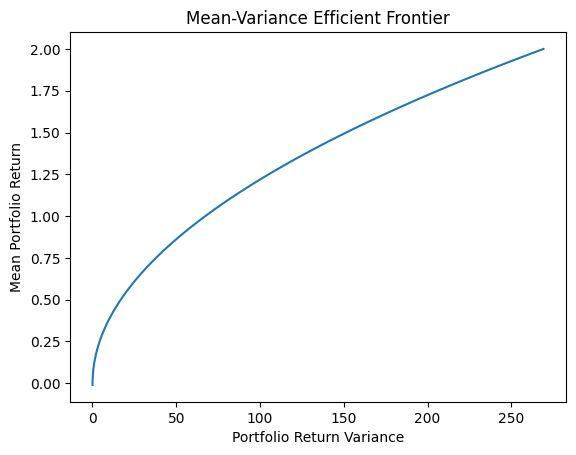

In [46]:
plt.plot(var_grid, mean_grid)
plt.xlabel('Portfolio Return Variance')
plt.ylabel('Mean Portfolio Return')
plt.title('Mean-Variance Efficient Frontier')